# **Table of Contents**
In this tutorial, we will go over the following:

1. **Writing your own [pyhealth.task](https://pyhealth.readthedocs.io/en/latest/api/tasks.html)** with two examples
2.   **Using it with the rest of the pipeline.**

As a reminder, **pyhealth.tasks** directly builds off of **pyhealth.datasets**.

![Image description](https://drive.google.com/uc?export=view&id=1hHJcavXqisH9JEMqEVtE4TqEg_E489l5)

In [ ]:
!pip install pyhealth

### **BaseTask**

There's a couple of things to keep in mind here. First, every task inherits the BaseTask class, which looks like



```
class BaseTask(ABC):
    task_name: str
    input_schema: Dict[str, str]
    output_schema: Dict[str, str]

    def pre_filter(self, df: pl.LazyFrame) -> pl.LazyFrame:
        return df

    @abstractmethod
    def __call__(self, patient) -> List[Dict]:
        raise NotImplementedError
```


It defines a couple of key things:


1. The call function where we process the extracted data into a usable format from each patient. **(Note: The patient variable here effectively just represents a sample unit defined by the pyhealth.dataset module earlier.)**



2. The input_schema and output_schema, which define the format of the model input and model output. This can range a wide variety of datatypes. While we offer [processors](https://github.com/sunlabuiuc/PyHealth/tree/master/pyhealth/processors) that take explicitly defined datatypes and processes them for use in training existing models on PyHealth. However, these pre-defined datatypes **are not required** and can effectively be anything for your purposes. However, We **recommend** schemas primarily for documentation purposes, and for direct use with our lightweight trainers.



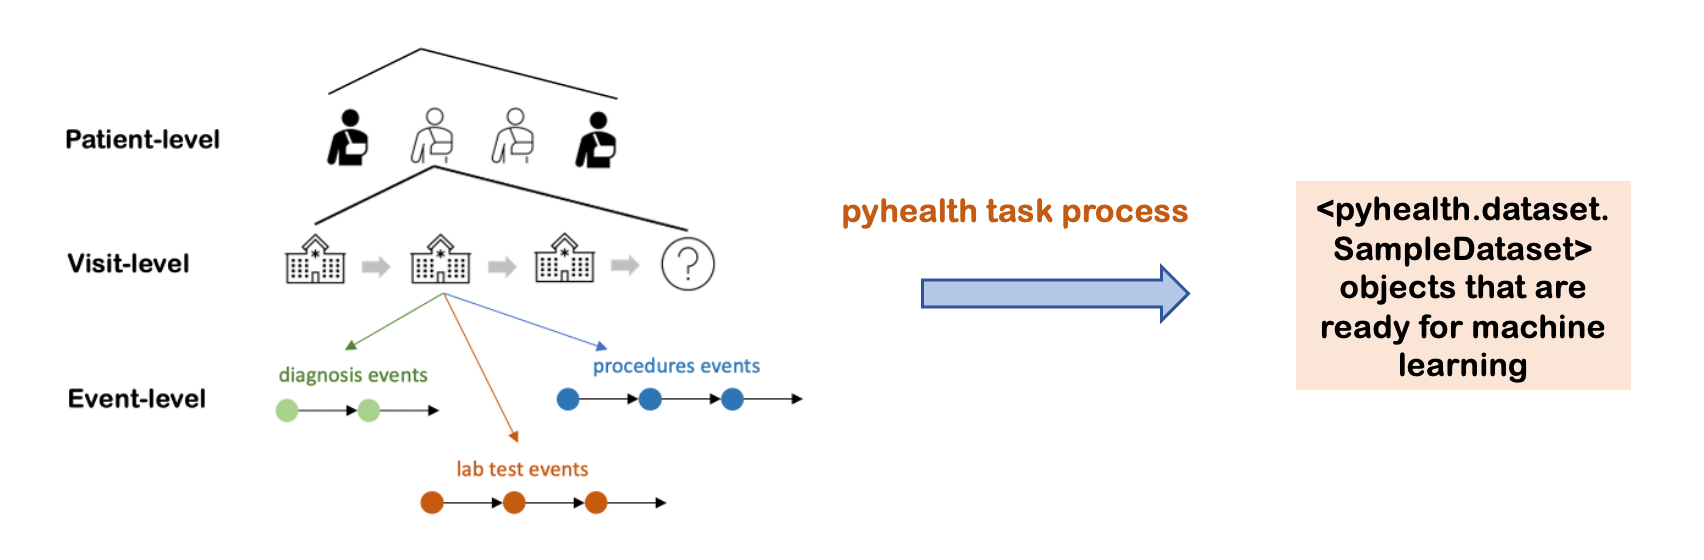

### **Example 1: Medical Coding**

Here, we want to construct a simple medical coding task where effectively we want to translate every piece of text in a patient's history to a set of medical codes. Here, you'll notice a couple of things:

1. The processing of data is functionally the same as exploring data with PyHealth datasets [here](https://colab.research.google.com/drive/1voSx7wEfzXfEf2sIfW6b-8p1KqMyuWxK?usp=sharing)
2. We have defined a 'text' input for our models and 'icd_codes' as our output. These explicitly outline how pyhealth models will interact with the "pyhealth.task" and for interested users, what the task is attempting to accomplish.
3. Here we only need to define 3 specific things:


```
input_schema : {"our feature identifier" : "processor_name"}
output_schema : {"our label" : "type of label"}
```



See the API for our processors [here](https://pyhealth.readthedocs.io/en/latest/api/processors.html). Each processor effectively defines how the processed data will be represented in tensor space. You can imagine it being equivalent to a tokenizer in LLMs, a image transform in medical imaging, and a static embedding model for various categorical models.

In [ ]:
from pyhealth.data import Patient
from pyhealth.tasks.base_task import BaseTask
from typing import Dict, List
from pyhealth.processors import TextProcessor, MultiLabelProcessor
import polars as pl
class MIMIC3ICD9Coding(BaseTask):
    """Medical coding task for MIMIC-III using ICD-9 codes.

    This task uses clinical notes to predict ICD-9 codes for a patient.

    Args:
        task_name: Name of the task
        input_schema: Definition of the input data schema
        output_schema: Definition of the output data schema
    """
    task_name: str = "mimic3_icd9_coding"
    input_schema: Dict[str, str] = {"text": TextProcessor}
    output_schema: Dict[str, str] = {"icd_codes": MultiLabelProcessor}

    def pre_filter(self, df: pl.LazyFrame) -> pl.LazyFrame:
        filtered_df = df.filter(
            pl.col("patient_id").is_in(
                df.filter(pl.col("event_type") == "noteevents")
                .select("patient_id")
                .unique()
                .collect()
                .to_series()
            )
        )
        return filtered_df

    def __call__(self, patient: Patient) -> List[Dict]:
        """Process a patient and extract the clinical notes and ICD-9 codes.

        Args:
            patient: Patient object containing events

        Returns:
            List of samples, each containing text and ICD codes
        """
        samples = []
        text = ""
        icd_codes = set()

        diagnoses_icd = patient.get_events(
            event_type="diagnoses_icd",
        )
        procedures_icd = patient.get_events(
            event_type="procedures_icd",
        )
        noteevents = patient.get_events(
            event_type="noteevents",
        )


        for note in noteevents:
            text += " " + note.text

        diagnoses_icd = [event.icd9_code for event in diagnoses_icd]
        procedures_icd = [event.icd9_code for event in procedures_icd]
        icd_codes = list(set(diagnoses_icd + procedures_icd))

        samples.append({
            "patient_id": patient.patient_id,
            "text": text,
            "icd_codes": icd_codes
        })

        return samples


### Connecting the medical coding task to the MIMIC3 dataset.

In [ ]:
from pyhealth.datasets import MIMIC3Dataset

root = "https://storage.googleapis.com/pyhealth/Synthetic_MIMIC-III"
dataset = MIMIC3Dataset(
    root=root,
    dataset_name="mimic3",
    tables=[
        "diagnoses_icd",
        "procedures_icd",
        "noteevents"
    ]
)


mimic3_coding = MIMIC3ICD9Coding()
samples = dataset.set_task(mimic3_coding)
# Print sample information
print(f"Total samples generated: {len(samples)}")
if len(samples) > 0:
    print("First sample:")
    print(f"  - Text length: {len(samples[0]['text'])} characters")
    print(f"  - Number of ICD codes: {len(samples[0]['icd_codes'])}")
    if len(samples[0]['icd_codes']) > 0:
        print(f"  - Sample ICD codes: {samples[0]['icd_codes'][:5] if len(samples[0]['icd_codes']) > 5 else samples[0]['icd_codes']}")


No config path provided, using default config


INFO:pyhealth.datasets.mimic3:No config path provided, using default config


Initializing mimic3 dataset from https://storage.googleapis.com/pyhealth/Synthetic_MIMIC-III (dev mode: False)


INFO:pyhealth.datasets.base_dataset:Initializing mimic3 dataset from https://storage.googleapis.com/pyhealth/Synthetic_MIMIC-III (dev mode: False)


Setting task mimic3_icd9_coding for mimic3 base dataset...


...

Worker 0 finished processing samples.



INFO:pyhealth.datasets.base_dataset:Worker 0 finished processing samples.


Cached processed samples to /root/.cache/pyhealth/54ab2756-e441-5796-8994-6521684b496b/tasks/mimic3_icd9_coding_f8cedbe4-72a8-53c3-922d-4cc8730f4c2d/samples_a8bb3952-788a-5bf6-877b-f1dc6baac85b.ld


INFO:pyhealth.datasets.base_dataset:Cached processed samples to /root/.cache/pyhealth/54ab2756-e441-5796-8994-6521684b496b/tasks/mimic3_icd9_coding_f8cedbe4-72a8-53c3-922d-4cc8730f4c2d/samples_a8bb3952-788a-5bf6-877b-f1dc6baac85b.ld


Total samples generated: 49993
First sample:
  - Text length: 2855 characters
  - Number of ICD codes: 7030
  - Sample ICD codes: tensor([0., 0., 0., 0., 0.])


#### Dataset Splitting for Training Purposes.

In [ ]:
from pyhealth.datasets import split_by_sample


train_dataset, val_dataset, test_dataset = split_by_sample(
    dataset=samples,
    ratios=[0.7, 0.1, 0.2]
)

In [ ]:
from pyhealth.datasets import get_dataloader


train_dataloader = get_dataloader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = get_dataloader(val_dataset, batch_size=32, shuffle=False)
test_dataloader = get_dataloader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
from pyhealth.models import TransformersModel
from pyhealth.trainer import Trainer
model = TransformersModel(
    model_name="emilyalsentzer/Bio_ClinicalBERT",
    dataset=samples,
)
trainer = Trainer(
    model=model,
    metrics=["f1_micro", "f1_macro", "f1_weighted"]
)
# crashes because colab doesn't have enough memory a lot of the times..
trainer.train(
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    epochs=1,
    monitor="f1_micro",  # Monitor f1_micro specifically
    optimizer_params={"lr": 5e-5}  # Using learning rate of 5e-5
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

INFO:pyhealth.trainer:loss: 0.0106


New best f1_micro score (0.0543) at epoch-0, step-1094


INFO:pyhealth.trainer:New best f1_micro score (0.0543) at epoch-0, step-1094


Loaded best model


INFO:pyhealth.trainer:Loaded best model


### **Example 2: [COVIDCXR](https://github.com/sunlabuiuc/PyHealth/blob/master/pyhealth/tasks/covid19_cxr_classification.py) X-ray Classification**

We illustrate this example to showcase two useful properties of PyHealth:
1. It does not need to be patient-centric and its formatting can be used for datasets that contain a lot of sub-files.
2. We offer a diverse set of existing datasets such that people do not need to manually process a bunch of things themselves.


In [ ]:
from typing import Any, Dict, List
from pyhealth.tasks.base_task import BaseTask


class COVID19CXRClassification(BaseTask):
    """A task for classifying chest disease from chest X-ray images.

    This task classifies chest X-ray images into different disease categories.
    It expects a single chest X-ray image per patient and returns the
    corresponding disease label.

    Attributes:
        task_name (str): The name of the task, set to
            "COVID19CXRClassification".
        input_schema (Dict[str, str]): The input schema specifying the required
            input format. Contains a single key "image" with value "image".
        output_schema (Dict[str, str]): The output schema specifying the output
            format. Contains a single key "disease" with value "multiclass".
    """

    task_name: str = "COVID19CXRClassification"
    input_schema: Dict[str, str] = {"image": "image"}
    output_schema: Dict[str, str] = {"disease": "multiclass"}

    def __call__(self, patient: Any) -> List[Dict[str, Any]]:
        """Process a patient's chest X-ray data to classify COVID-19 status.

        Args:
            patient: A patient object containing chest X-ray data.

        Returns:
            List[Dict[str, Any]]: A list containing a single dictionary with:
                - "image": Path to the chest X-ray image
                - "disease": The disease classification label

        Raises:
            AssertionError: If the patient has more than one chest X-ray event.
        """
        event = patient.get_events(event_type="covid19_cxr")
        # There should be only one event
        assert len(event) == 1
        event = event[0]
        image = event.path
        disease = event.label
        return [{"image": image, "disease": disease}]

#### We apply this task function on the COVID19CXR dataset

In [ ]:
!wget -N https://storage.googleapis.com/pyhealth/covid19_cxr_data/archive.zip
!unzip -q -o archive.zip
!ls -1 COVID-19_Radiography_Dataset

--2026-03-20 17:13:58--  https://storage.googleapis.com/pyhealth/covid19_cxr_data/archive.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.4.207, 64.233.170.207, 142.251.10.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.4.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 816029038 (778M) [application/zip]
Saving to: ‘archive.zip’

archive.zip         100%[===================>] 778.23M  19.7MB/s    in 45s     

2026-03-20 17:14:44 (17.3 MB/s) - ‘archive.zip’ saved [816029038/816029038]

COVID
COVID.metadata.xlsx
Lung_Opacity
Lung_Opacity.metadata.xlsx
Normal
Normal.metadata.xlsx
README.md.txt
'Viral Pneumonia'
'Viral Pneumonia.metadata.xlsx'


In [ ]:
from pyhealth.datasets import COVID19CXRDataset


root = "/content/COVID-19_Radiography_Dataset"
cxr_dataset = COVID19CXRDataset(root)

No config path provided, using default config


INFO:pyhealth.datasets.covid19_cxr:No config path provided, using default config


Initializing covid19_cxr dataset from /content/COVID-19_Radiography_Dataset (dev mode: False)


INFO:pyhealth.datasets.base_dataset:Initializing covid19_cxr dataset from /content/COVID-19_Radiography_Dataset (dev mode: False)


In [ ]:
cxr_task = COVID19CXRClassification()
cxr_samples = cxr_dataset.set_task(cxr_task)

Setting task COVID19CXRClassification for covid19_cxr base dataset...


INFO:pyhealth.datasets.base_dataset:Setting task COVID19CXRClassification for covid19_cxr base dataset...


No cache_dir provided. Using default cache dir: /root/.cache/pyhealth/ebe82b39-fbfc-5f16-8c90-0a3824c58fab


INFO:pyhealth.datasets.base_dataset:No cache_dir provided. Using default cache dir: /root/.cache/pyhealth/ebe82b39-fbfc-5f16-8c90-0a3824c58fab


Applying task transformations on data with 1 workers...


...

100%|██████████| 21165/21165 [01:10<00:00, 298.66it/s]

Worker 0 finished processing samples.



INFO:pyhealth.datasets.base_dataset:Worker 0 finished processing samples.


Cached processed samples to /root/.cache/pyhealth/ebe82b39-fbfc-5f16-8c90-0a3824c58fab/tasks/COVID19CXRClassification_f8cedbe4-72a8-53c3-922d-4cc8730f4c2d/samples_e687140b-9b8b-58b5-9d00-d0470522fcfa.ld


INFO:pyhealth.datasets.base_dataset:Cached processed samples to /root/.cache/pyhealth/ebe82b39-fbfc-5f16-8c90-0a3824c58fab/tasks/COVID19CXRClassification_f8cedbe4-72a8-53c3-922d-4cc8730f4c2d/samples_e687140b-9b8b-58b5-9d00-d0470522fcfa.ld


In [ ]:
cxr_samples[0]

{'image': tensor([[[0.4549, 0.0627, 0.0000,  ..., 0.0039, 0.0392, 0.3098],
          [0.1255, 0.0157, 0.0000,  ..., 0.0039, 0.0118, 0.0784],
          [0.0078, 0.0000, 0.0000,  ..., 0.0039, 0.0196, 0.0588],
          ...,
          [0.2549, 0.2431, 0.3020,  ..., 0.0078, 0.0196, 0.0471],
          [0.3294, 0.2745, 0.3255,  ..., 0.0039, 0.0392, 0.1725],
          [0.4863, 0.3176, 0.3412,  ..., 0.0000, 0.0784, 0.4314]]]),
 'disease': tensor(0)}

#### Please notice how we have everything already in tensor format for training purposes from our processors. To keep things brief, we'll stop here.

For the full tutorial on CXR classification with PyHealth, see [here](https://colab.research.google.com/drive/18vK23gyI1LjWbTgkq4f99yDZA3A7Pxp9?usp=sharing).

If you find it useful, please give us a star ⭐ (fork, and watch) at https://github.com/sunlabuiuc/PyHealth.

Thanks very much for your support!